In [11]:
import numpy as np
import preprocess as pp

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# paths
infile = "../data/raw_activity.csv"

# hyperparameters
test_ratio = 0.3
batch_size = 64
learning_rate = 0.00001
epochs = 15
smoothing_factor = 0.2

In [ ]:
## preprocess data  ##

# split features from labels, stratified train/test split
x_train, x_test, y_train, y_test = pp.load_data(infile, test_ratio)

# apply SMOTE
x_train, y_train = pp.apply_smote(x_train, y_train)
x_train = pp.min_max_scale(x_train)
x_test = pp.preprocess(x_test, s=smoothing_factor)

print(f"Train size: {len(x_train)} | Test size: {len(x_test)}")
print(f"Train class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

Train size: 16804 | Test size: 5263
Train class distribution: {np.int64(0): np.int64(8402), np.int64(1): np.int64(8402)}
Test class distribution:  {np.int64(0): np.int64(1661), np.int64(1): np.int64(3602)}


Training Data:


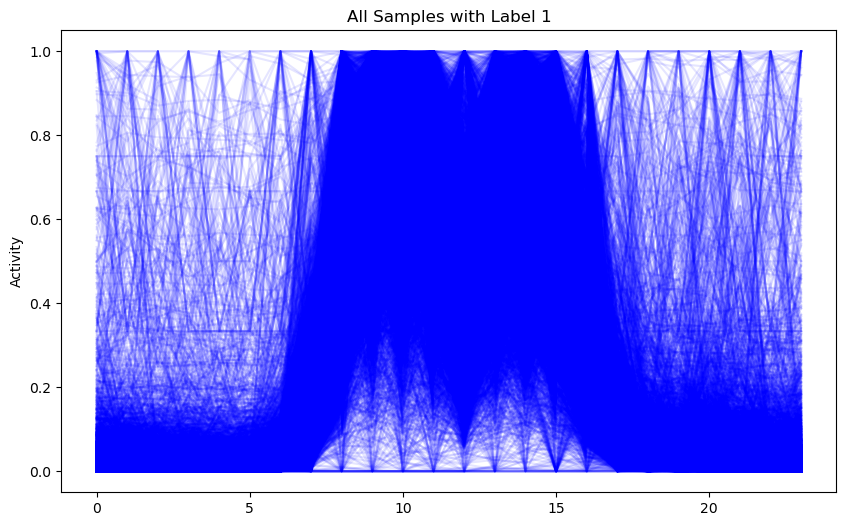

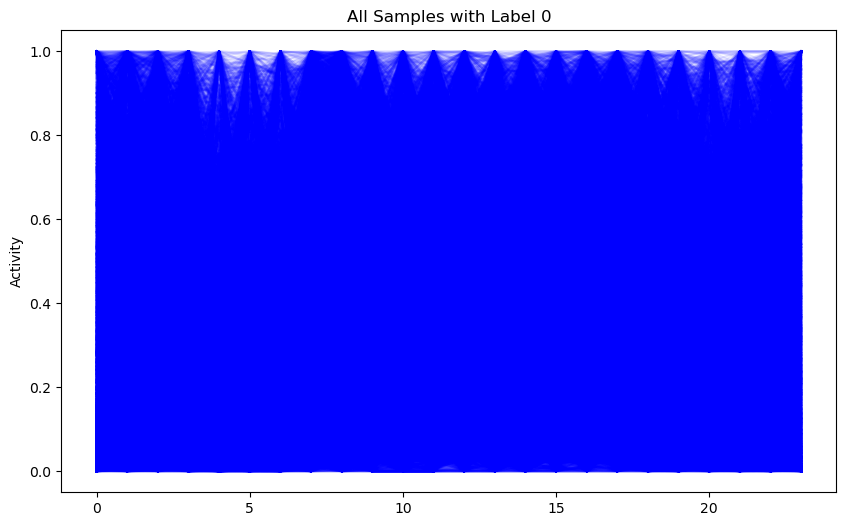

Test Data:


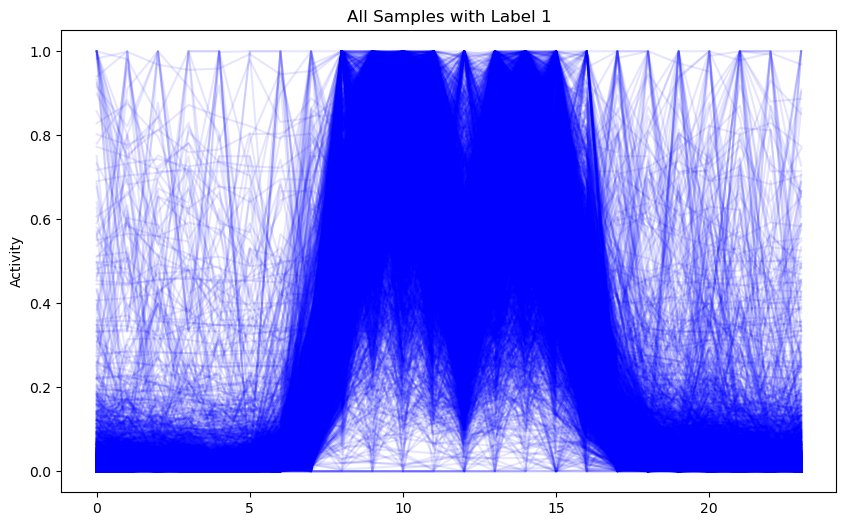

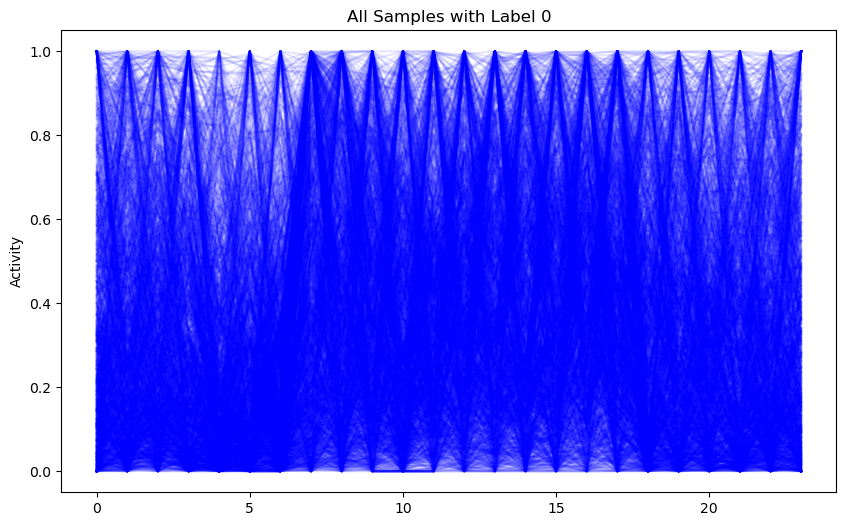

In [ ]:
## plot data ##

print("Training Data:")
pp.plot_all(label=1, x=x_train, y=y_train)
pp.plot_all(label=0, x=x_train, y=y_train)

print("Test Data:")
pp.plot_all(label=1, x=x_test, y=y_test)
pp.plot_all(label=0, x=x_test, y=y_test)

In [ ]:
## datasets and loaders ##

class PacketVolumeDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

train_dataset = PacketVolumeDataset(x_train, y_train)
test_dataset = PacketVolumeDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
## model ##

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=24, hidden_dim=64, dropout_rate=0.3):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.linear_relu_stack(x)


model = NeuralNetwork()
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
## training ##

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    size = len(dataloader.dataset)

    for batch, (x, y) in enumerate(dataloader):
        pred = model(x).squeeze(1)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        if batch % 100 == 0:
            print(f"  loss: {loss.item():>7f}  [{batch * len(x):>5d}/{size:>5d}]")

    return total_loss / len(dataloader)

def test_loop(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            logits = model(x).squeeze(1)
            total_loss += loss_fn(logits, y).item()
            preds = (torch.sigmoid(logits) > 0.5).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy().astype(int))

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"  Avg loss: {avg_loss:.6f} | Accuracy: {100 * accuracy:.1f}%")
    return avg_loss

# class-weighted loss
num_pos = (train_dataset.y == 1).sum()
num_neg = (train_dataset.y == 0).sum()
pos_weight = (num_neg / num_pos).clone().detach()
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

train_losses, test_losses = [], []

for t in range(epochs):
    print(f"Epoch {t + 1}/{epochs}\n" + "-" * 30)
    train_losses.append(train_loop(train_loader, model, loss_fn, optimizer))
    test_losses.append(test_loop(test_loader, model, loss_fn))

print("\nTraining complete.")

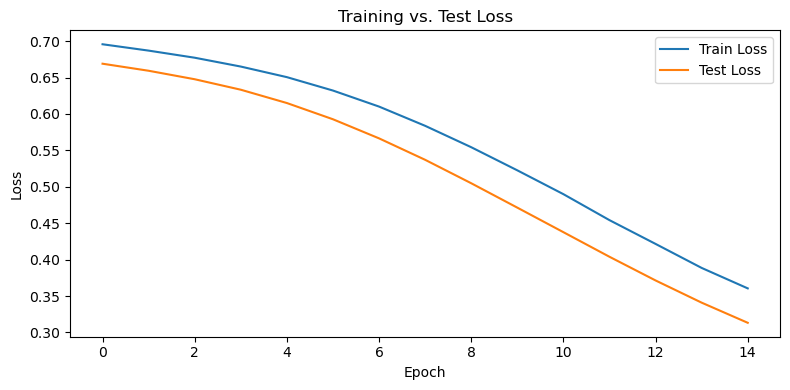

In [ ]:
## plot loss ##

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Test Loss")
plt.legend()
plt.tight_layout()
plt.show()

EVALUATION RESULTS
               precision    recall  f1-score   support

   Normal (0)     0.9121    0.9121    0.9121      1661
Automated (1)     0.9595    0.9595    0.9595      3602

     accuracy                         0.9445      5263
    macro avg     0.9358    0.9358    0.9358      5263
 weighted avg     0.9445    0.9445    0.9445      5263

ROC-AUC Score: 0.9774


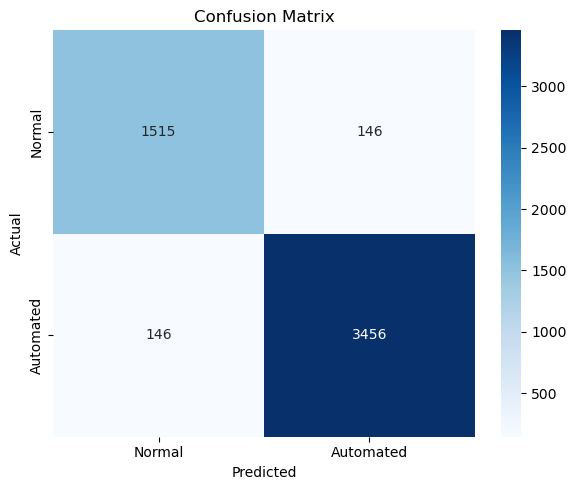

In [ ]:
## eval ##

def evaluate_model(model, dataloader, threshold=0.5):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for x, y in dataloader:
            logits = model(x).squeeze(1)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).long()
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy().astype(int))

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    print("=" * 50)
    print("EVALUATION RESULTS")
    print("=" * 50)
    print(classification_report(
        all_labels, all_preds,
        target_names=["Normal (1)", "Automated (0)"],
        digits=4
    ))
    auc = roc_auc_score(all_labels, all_probs)
    print(f"ROC-AUC Score: {auc:.4f}")

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Automated"],
                yticklabels=["Normal", "Automated"])
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
        "auc": auc,
    }

metrics = evaluate_model(model, test_loader)

SAMPLE INFERENCE


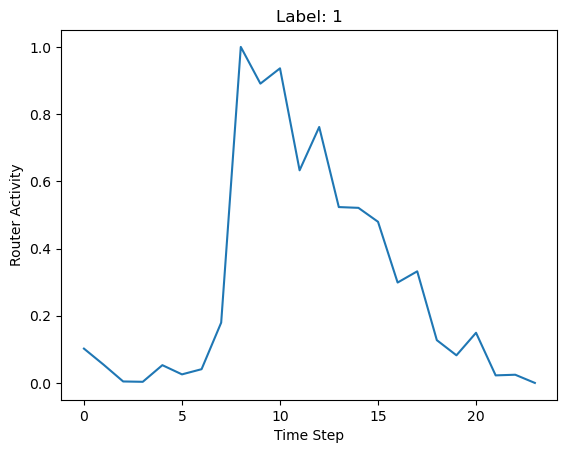

[✓] Sample  1 | Expected:    Normal | Predicted:    Normal | Confidence: 0.7740


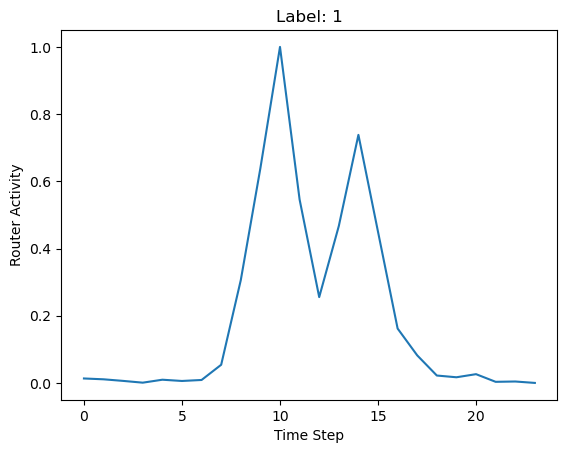

[✓] Sample  2 | Expected:    Normal | Predicted:    Normal | Confidence: 0.7891


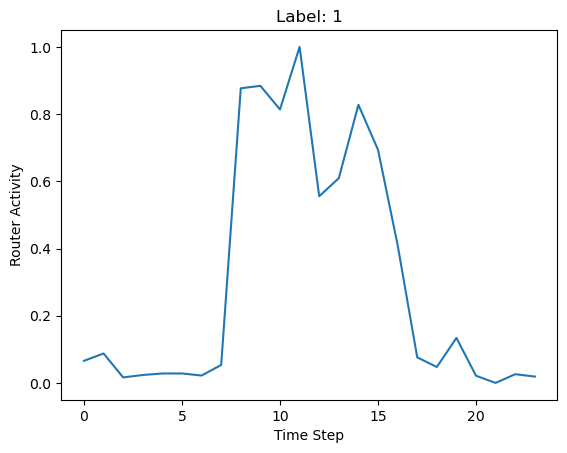

[✓] Sample  3 | Expected:    Normal | Predicted:    Normal | Confidence: 0.8368


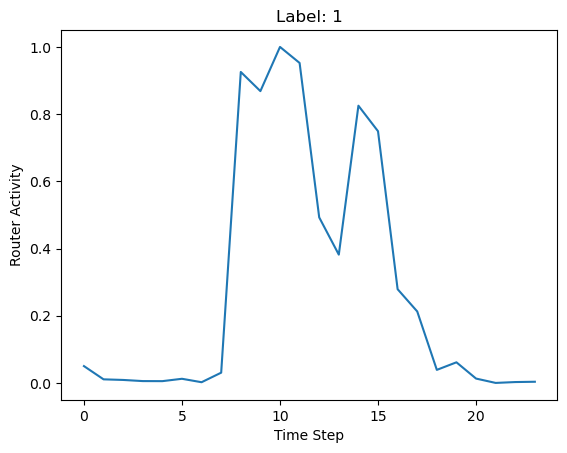

[✓] Sample  4 | Expected:    Normal | Predicted:    Normal | Confidence: 0.8369


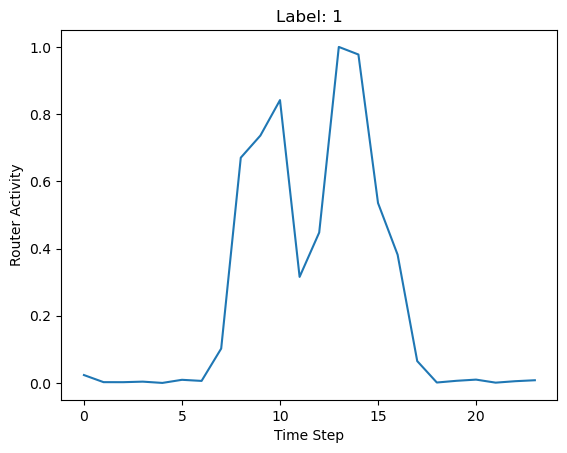

[✓] Sample  5 | Expected:    Normal | Predicted:    Normal | Confidence: 0.8454


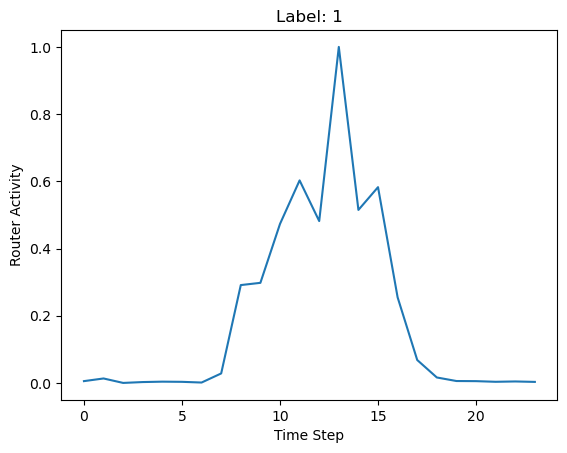

[✓] Sample  6 | Expected:    Normal | Predicted:    Normal | Confidence: 0.7803


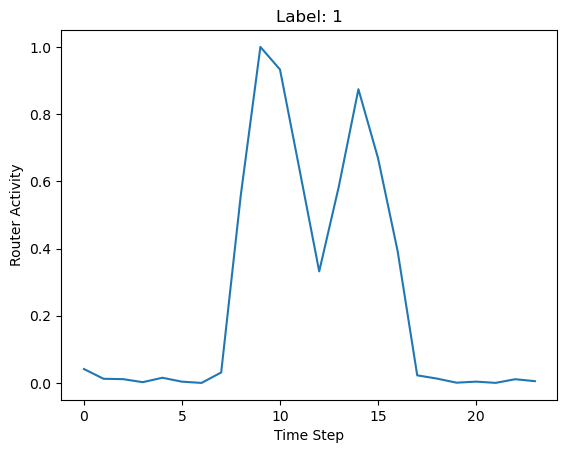

[✓] Sample  7 | Expected:    Normal | Predicted:    Normal | Confidence: 0.8455


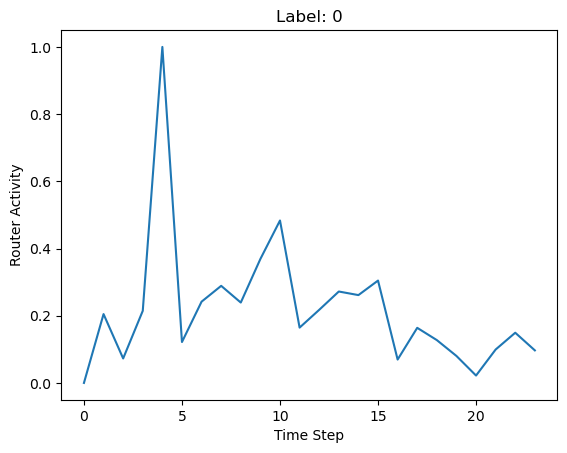

[✓] Sample  8 | Expected: Automated | Predicted: Automated | Confidence: 0.4698


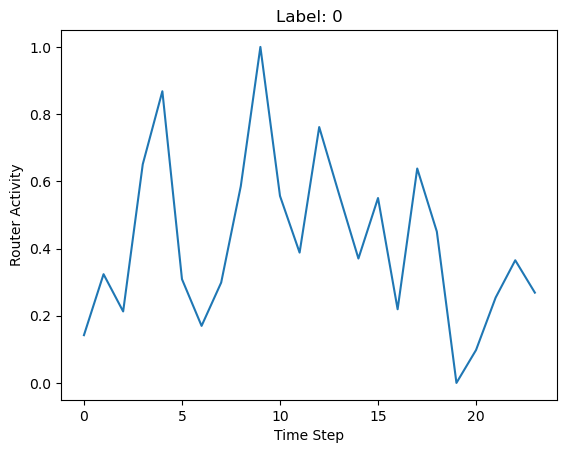

[✓] Sample  9 | Expected: Automated | Predicted: Automated | Confidence: 0.3400


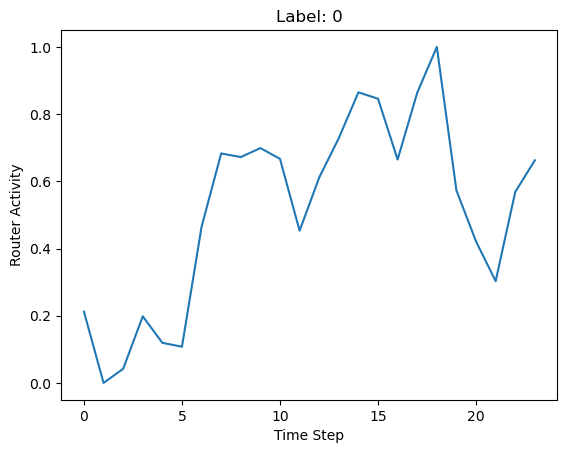

[✓] Sample 10 | Expected: Automated | Predicted: Automated | Confidence: 0.2300


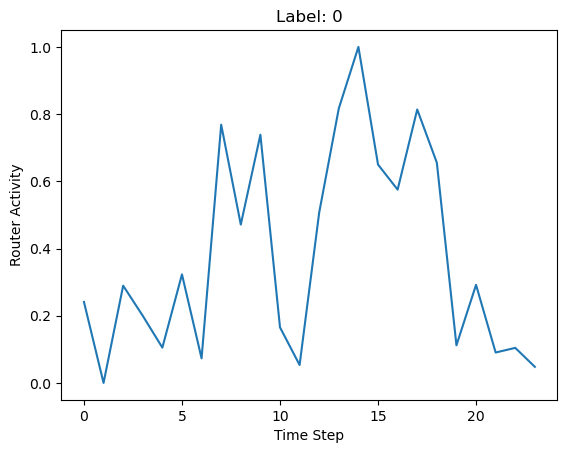

[✓] Sample 11 | Expected: Automated | Predicted: Automated | Confidence: 0.3736


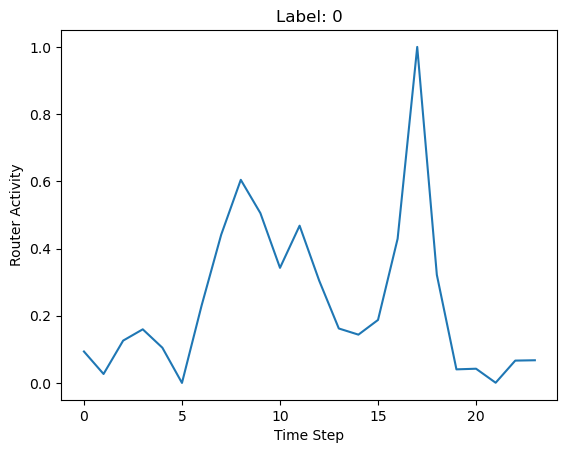

[✓] Sample 12 | Expected: Automated | Predicted: Automated | Confidence: 0.3273


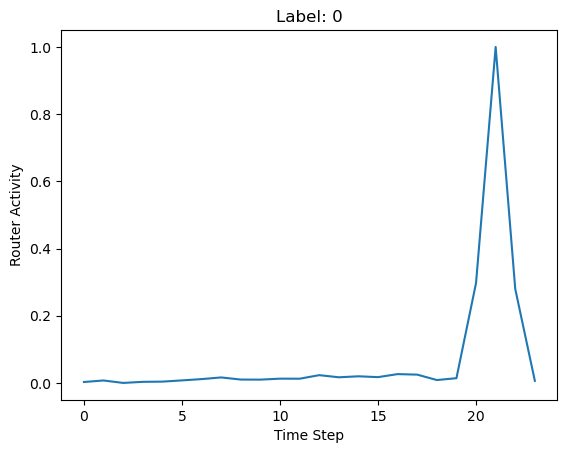

[✓] Sample 13 | Expected: Automated | Predicted: Automated | Confidence: 0.3587


In [ ]:
## sample inference ##

fake_x = np.array([
    [1742574, 1309301, 854980, 845749, 1295418, 1046669, 1186644, 2444318, 9892404, 8900858, 9314173, 6559351, 7729406, 5566068, 5545285, 5168333, 3527205, 3830412, 1970841, 1561391, 2170332, 1019496, 1036777, 815651],
    [2846863, 2793026, 2690025, 2575829, 2766404, 2685467, 2749883, 3734520, 9210518, 16453809, 24299262, 14426791, 8111879, 12710529, 18608996, 12337080, 6077771, 4341472, 3037579, 2924926, 3125765, 2630030, 2651303, 2559211],
    [1286160, 1404790, 1018436, 1057457, 1081580, 1082207, 1048473, 1219347, 5687328, 5726489, 5344958, 6355086, 3944064, 4235216, 5420715, 4693978, 3157104, 1342014, 1186356, 1656127, 1045185, 929342, 1070158, 1031838],
    [2723543, 2521926, 2512656, 2495396, 2494409, 2530369, 2478070, 2623434, 7202134, 6910320, 7583243, 7339181, 4987902, 4420728, 6688413, 6299537, 3894323, 3555556, 2666046, 2781218, 2533726, 2467380, 2480560, 2485219],
    [661037, 513933, 513262, 524504, 497990, 562433, 539658, 1209198, 5164137, 5622412, 6356792, 2694582, 3613660, 7458493, 7301338, 4224568, 3153765, 950387, 506303, 541752, 566517, 503590, 533758, 553445],
    [2565792, 2752844, 2439341, 2499970, 2528265, 2515878, 2466449, 3106682, 9326992, 9484279, 13630762, 16695352, 13832456, 26091308, 14616971, 16219629, 8462756, 4051975, 2822737, 2572992, 2564315, 2518893, 2542810, 2511258],
    [3278669, 3030133, 3020349, 2943227, 3056234, 2956289, 2924279, 3191551, 7715183, 11500597, 10923847, 8359437, 5771335, 7937038, 10420633, 8662505, 6290151, 3117591, 3035830, 2930451, 2957221, 2925588, 3018833, 2969252],
    [2700895, 2809247, 2739390, 2814357, 3229762, 2765273, 2828796, 2853696, 2827387, 2896028, 2956544, 2787954, 2815954, 2844773, 2839134, 2861996, 2737680, 2787604, 2768300, 2743334, 2712500, 2753477, 2779897, 2752114],
    [1605712, 1779570, 1673335, 2093008, 2301180, 1765413, 1632180, 1755669, 2030415, 2427509, 2002657, 1841115, 2199058, 2010009, 1824218, 1996695, 1679604, 2080851, 1901068, 1469559, 1563360, 1712924, 1819248, 1726962],
    [9545025, 7253867, 7707477, 9395239, 8542984, 8416696, 12274906, 14630499, 14514380, 14803256, 14457000, 12146478, 13855758, 15123810, 16595177, 16389480, 14435881, 16582528, 18055188, 13440338, 11801108, 10525630, 13394189, 14410410],
    [5276968, 4299290, 5473130, 5109551, 4725551, 5609094, 4595799, 7416264, 6210408, 7294766, 4970169, 4515829, 6356154, 7612762, 8354584, 6934709, 6632063, 7599506, 6957316, 4752987, 5483198, 4666284, 4722537, 4493462],
    [1018622, 948948, 1052428, 1087420, 1030414, 921221, 1160806, 1380651, 1550899, 1447597, 1278008, 1408723, 1238199, 1089994, 1070918, 1116492, 1368248, 1962927, 1256414, 963262, 965265, 921791, 990433, 991475],
    [4276720, 4373242, 4217897, 4287024, 4300101, 4378906, 4460862, 4566716, 4431801, 4426951, 4489007, 4485787, 4710932, 4576262, 4638951, 4585624, 4778249, 4745055, 4400494, 4518881, 10569899, 25575688, 10190193, 4350815]
])
fake_y = np.array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

fake_x_proc = pp.preprocess(fake_x, s=smoothing_factor)
fake_x_tensor = torch.tensor(fake_x_proc, dtype=torch.float32)

label_names = {1: "Normal", 0: "Automated"}

print("=" * 55)
print("SAMPLE INFERENCE")
print("=" * 55)

model.eval()
with torch.no_grad():
    for i, sample in enumerate(fake_x_tensor):
        pp.plot_sample(x=sample.numpy(), y=fake_y[i])
        prob = torch.sigmoid(model(sample)).item()
        predicted_class = int(prob > 0.5)
        status = "✓" if predicted_class == fake_y[i] else "✗"
        print(
            f"[{status}] Sample {i+1:>2d} | "
            f"Expected: {label_names[fake_y[i]]:>9s} | "
            f"Predicted: {label_names[predicted_class]:>9s} | "
            f"Confidence: {prob:.4f}"
        )